In [1]:
import algos.net as nn

import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split


data = load_digits()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

y_train = np.eye(10)[y_train.astype(int)]  # Convert to one-hot
y_test = np.eye(10)[y_test.astype(int)]

input_size = X.shape[1]
output_size = len(np.unique(y))

In [2]:
layers = [
    nn.Layer(input_size,128),
    nn.ReLU(),
    nn.Layer(128, 64),
    nn.ReLU(),
    nn.Layer(64, output_size),
    nn.Softmax()        
]

X_train = X_train.reshape(X_train.shape[0], 1, 8*8)
X_train /= 255
X_test = X_test.reshape(X_test.shape[0], 1, 8*8)
X_test /= 255

net = nn.NeuralNet(layers=layers, verbose=1)

net.fit(X_train, y_train, minibatches=10000, eta=0.1)


Minibatch: 0/10000,
Error: 2.5918184543173526.

Minibatch: 100/10000,
Error: 1.9915979128842811.

Minibatch: 200/10000,
Error: 1.5661708600823112.

Minibatch: 300/10000,
Error: 1.0343360972250437.

Minibatch: 400/10000,
Error: 1.026747179028248.

Minibatch: 500/10000,
Error: 0.7619643594507972.

Minibatch: 600/10000,
Error: 0.42674905553218545.

Minibatch: 700/10000,
Error: 0.5313997723272919.

Minibatch: 800/10000,
Error: 0.4550198862555156.

Minibatch: 900/10000,
Error: 0.5374979206456503.

Minibatch: 1000/10000,
Error: 0.45563627640979165.

Minibatch: 1100/10000,
Error: 0.37934729966019504.

Minibatch: 1200/10000,
Error: 0.25040789218761494.

Minibatch: 1300/10000,
Error: 0.17667587955911593.

Minibatch: 1400/10000,
Error: 0.16178365109750276.

Minibatch: 1500/10000,
Error: 0.24083558347635173.

Minibatch: 1600/10000,
Error: 0.3587510666846848.

Minibatch: 1700/10000,
Error: 0.4020838227504938.

Minibatch: 1800/10000,
Error: 0.21379001191201874.

Minibatch: 1900/10000,
Error: 0.2061

In [3]:
out = net.predict(X_test)
cm = np.zeros((10,10), dtype="uint32")
for i in range(len(y_test)):
    cm[np.argmax(y_test[i]),np.argmax(out[i])] += 1

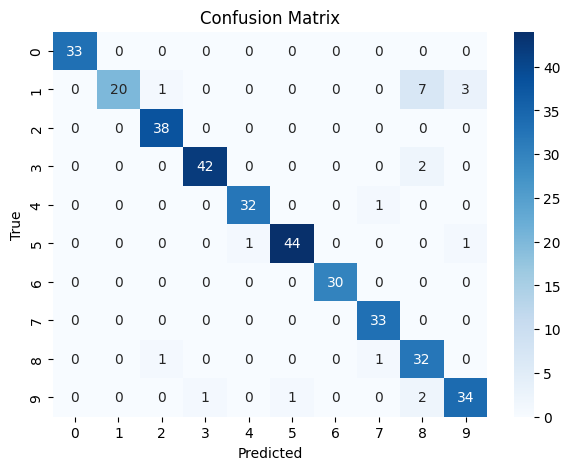

accuracy = 0.939


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
print("accuracy = %0.3f" % (np.diag(cm).sum() / cm.sum(),))
